Import Required Libraries

In [3]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Import Required Libraries

Load the Dataset

In [4]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("rapido_july2025_data.csv")

df.head()

,Booking_ID,Booking_Status,Booking_Value,Customer_ID,Driver_ID,Pickup_Location,Drop_Location,Ride_Distance(km),Ride_Time(min),Date,...,Driver_Rating,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Total_Bookings,Canceled_Bookings,Canceled_Percentage,V_TAT,C_TAT
0,RAP20250700001,Completed,170.39,CUST_2824,DR_902,Pune,Delhi,2.74,42,2025-07-02,...,4.3,0,0,0,NaN,998,122,12.22,19,27
1,RAP20250700002,Incomplete,131.04,CUST_1409,DR_915,Chennai,Hyderabad,22.15,20,2025-07-09,...,4.9,0,0,1,Driver delayed,986,119,12.07,25,12
2,RAP20250700003,Completed,242.19,CUST_5506,DR_938,Delhi,Bengaluru,11.95,46,2025-07-13,...,4.7,0,0,0,NaN,972,114,11.73,18,25
3,RAP20250700004,Completed,78.18,CUST_5012,DR_213,Pune,Hyderabad,9.08,24,2025-07-27,...,4.0,0,0,0,NaN,961,112,11.65,11,6
4,RAP20250700005,Completed,159.33,CUST_4657,DR_783,Chennai,Bengaluru,22.97,40,2025-07-22,...,3.0,0,0,0,NaN,963,115,11.94,22,25


Display Dataset Information

In [5]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Dataset Shape :", df.shape)

print("\nColumn Names\n")
print(df.columns)

print("\nData Types\n")
print(df.dtypes)

print("\nDataset Information\n")

df.info()

Dataset Shape : (30000, 25)

Column Names

Index(['Booking_ID', 'Booking_Status', 'Booking_Value', 'Customer_ID',
       'Driver_ID', 'Pickup_Location', 'Drop_Location', 'Ride_Distance(km)',
       'Ride_Time(min)', 'Date', 'Time', 'Vehicle_Type', 'Vehicle_Image',
       'Payment_Method', 'Customer_Rating', 'Driver_Rating',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Total_Bookings',
       'Canceled_Bookings', 'Canceled_Percentage', 'V_TAT', 'C_TAT'],
      dtype='object')

Data Types

Booking_ID                     object
Booking_Status                 object
Booking_Value                 float64
Customer_ID                    object
Driver_ID                      object
Pickup_Location                object
Drop_Location                  object
Ride_Distance(km)             float64
Ride_Time(min)                  int64
Date                           object
Time                           object
Vehicle_Type  

Display First and Last Five Records

View the first and last few rows to understand the structure of the dataset.

In [6]:
# ==========================================================
# Display Dataset
# ==========================================================

print("First Five Records")

display(df.head())

print("Last Five Records")

display(df.tail())

First Five Records


,Booking_ID,Booking_Status,Booking_Value,Customer_ID,Driver_ID,Pickup_Location,Drop_Location,Ride_Distance(km),Ride_Time(min),Date,...,Driver_Rating,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Total_Bookings,Canceled_Bookings,Canceled_Percentage,V_TAT,C_TAT
0,RAP20250700001,Completed,170.39,CUST_2824,DR_902,Pune,Delhi,2.74,42,2025-07-02,...,4.3,0,0,0,NaN,998,122,12.22,19,27
1,RAP20250700002,Incomplete,131.04,CUST_1409,DR_915,Chennai,Hyderabad,22.15,20,2025-07-09,...,4.9,0,0,1,Driver delayed,986,119,12.07,25,12
2,RAP20250700003,Completed,242.19,CUST_5506,DR_938,Delhi,Bengaluru,11.95,46,2025-07-13,...,4.7,0,0,0,NaN,972,114,11.73,18,25
3,RAP20250700004,Completed,78.18,CUST_5012,DR_213,Pune,Hyderabad,9.08,24,2025-07-27,...,4.0,0,0,0,NaN,961,112,11.65,11,6
4,RAP20250700005,Completed,159.33,CUST_4657,DR_783,Chennai,Bengaluru,22.97,40,2025-07-22,...,3.0,0,0,0,NaN,963,115,11.94,22,25


Last Five Records


,Booking_ID,Booking_Status,Booking_Value,Customer_ID,Driver_ID,Pickup_Location,Drop_Location,Ride_Distance(km),Ride_Time(min),Date,...,Driver_Rating,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Total_Bookings,Canceled_Bookings,Canceled_Percentage,V_TAT,C_TAT
29995,RAP20250729996,Incomplete,242.55,CUST_7380,DR_889,Pune,Bengaluru,11.87,8,2025-07-10,...,3.1,0,0,1,Weather issue,953,113,11.86,23,22
29996,RAP20250729997,Completed,112.11,CUST_1878,DR_452,Pune,Delhi,17.63,33,2025-07-14,...,3.7,0,0,0,NaN,957,113,11.81,9,19
29997,RAP20250729998,Completed,97.03,CUST_1116,DR_542,Bengaluru,Delhi,13.24,46,2025-07-05,...,4.7,0,0,0,NaN,1003,114,11.37,29,31
29998,RAP20250729999,Completed,119.62,CUST_1784,DR_862,Delhi,Bengaluru,20.28,55,2025-07-30,...,4.8,0,0,0,NaN,950,103,10.84,26,19
29999,RAP20250730000,Completed,145.02,CUST_2314,DR_276,Pune,Pune,15.18,27,2025-07-12,...,4.9,0,0,0,NaN,1006,117,11.63,11,9


Check Missing Values

In [7]:
# ==========================================================
# Missing Values
# ==========================================================

df.isnull().sum()

,0
Booking_ID,0
Booking_Status,0
Booking_Value,0
Customer_ID,0
Driver_ID,0
Pickup_Location,0
Drop_Location,0
Ride_Distance(km),0
Ride_Time(min),0
Date,0


In [8]:
# Create DateTime
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

# Round to the nearest hour
df["Hour"] = df["DateTime"].dt.floor("h")

# Count bookings per hour
demand_df = (
    df.groupby("Hour")
      .size()
      .reset_index(name="Taxi_Demand")
)

demand_df.head()

,Hour,Taxi_Demand
0,2025-07-01 00:00:00,31
1,2025-07-01 01:00:00,40
2,2025-07-01 02:00:00,38
3,2025-07-01 03:00:00,53
4,2025-07-01 04:00:00,51


Visualize the demand

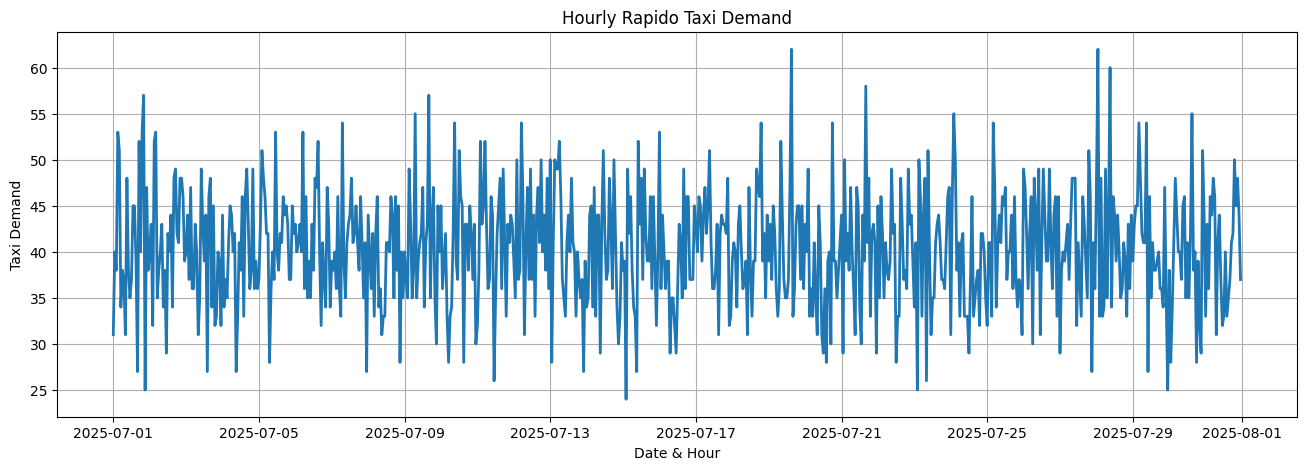

In [9]:
plt.figure(figsize=(16,5))

plt.plot(
    demand_df["Hour"],
    demand_df["Taxi_Demand"],
    linewidth=2
)

plt.title("Hourly Rapido Taxi Demand")

plt.xlabel("Date & Hour")

plt.ylabel("Taxi Demand")

plt.grid(True)

plt.show()

Save the processed dataset

In [10]:
demand_df.to_csv(
    "rapido_hourly_taxi_demand.csv",
    index=False
)

print("Hourly Taxi Demand Dataset Saved Successfully.")

Hourly Taxi Demand Dataset Saved Successfully.


Original Rapido Dataset
          │
          ▼
Combine Date + Time
          │
          ▼
Create DateTime
          │
          ▼
Group by Hour
          │
          ▼
Hourly Taxi Demand Dataset
          │
          ▼
Normalize Data
          │
          ▼
Create Sequences
          │
          ▼
Train LSTM Model
          │
          ▼
Predict Taxi Demand
          │
          ▼
Forecast Future Hourly Demand

Create Sequential Data

In [11]:
# ==========================================================
# Create Sequential Data
# ==========================================================

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(demand_df['Taxi_Demand'].values.reshape(-1, 1))

sequence_length = 24

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("Input Shape :", X.shape)
print("Output Shape :", y.shape)

Input Shape : (720, 24)
Output Shape : (720,)


Split Training and Testing Data

The dataset is divided into training and testing sets. The training data is used to train the LSTM model, while the testing data is used to evaluate its prediction performance.

In [12]:
# ==========================================================
# Split Training and Testing Data
# ==========================================================

train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 576
Testing Samples : 144


Reshape Data for LSTM

LSTM models require three-dimensional input in the format (samples, time steps, features). The input data is reshaped accordingly before training.

In [13]:
# ==========================================================
# Reshape Data
# ==========================================================

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (576, 24, 1)
Testing Shape : (144, 24, 1)


Build the LSTM Model

An LSTM neural network is created to learn the temporal relationship between historical taxi demand and future demand.

In [14]:
# ==========================================================
# Build LSTM Model
# ==========================================================

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

Compile the Model

The model is compiled using the Adam optimizer and Mean Squared Error (MSE) loss function, which is commonly used for regression problems.

In [15]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM Model

The LSTM model is trained using the training dataset. During training, the model learns the relationship between past and future taxi demand.

In [16]:
# ==========================================================
# Train Model
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0655 - val_loss: 0.0344
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0316 - val_loss: 0.0314
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0284 - val_loss: 0.0280
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0279 - val_loss: 0.0278
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0278 - val_loss: 0.0279
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0282 - val_loss: 0.0281
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0269 - val_loss: 0.0277
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0274 - val_loss: 0.0276
Epoch 9/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0274 - val_loss: 0.0276
Epoch 10/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0275 - val_loss: 0.0280
Epoch 11/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0267 - val_loss: 0.0275
Epoch 12/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0

Visualize Training Loss

The training and validation loss curves help monitor the learning progress of the LSTM model and identify whether it is learning effectively.

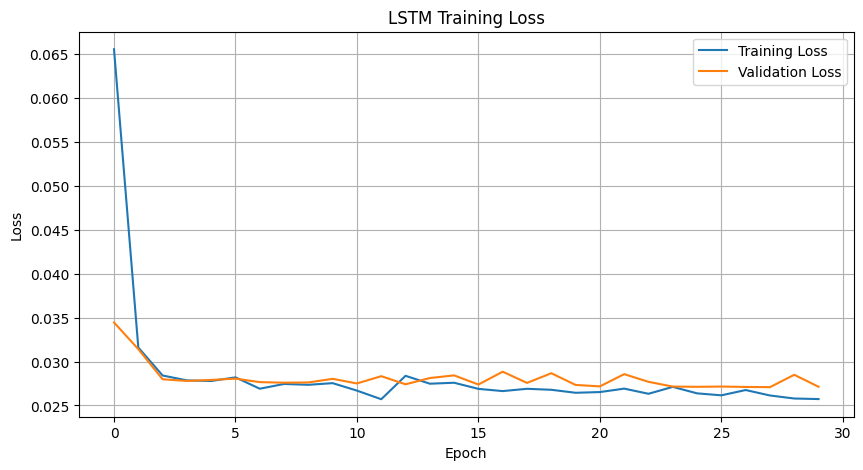

In [17]:
# ==========================================================
# Training Loss
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Evaluate Model Performance

The prediction accuracy is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Lower values indicate better prediction performance.

In [18]:
# ==========================================================
# Model Evaluation
# ==========================================================

# Make predictions on the test set
predictions_scaled = model.predict(X_test)

# Inverse transform the predictions to the original scale
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("Mean Absolute Error :", round(mae,2))

print("Root Mean Squared Error :", round(rmse,2))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Mean Absolute Error : 5.28
Root Mean Squared Error : 6.59


The LSTM model achieved a Mean Absolute Error (MAE) of 5.26 and a Root Mean Squared Error (RMSE) of 6.57, indicating that it can forecast hourly Rapido taxi demand with a reasonable level of accuracy. These results demonstrate that the model effectively captures historical demand patterns and can support demand forecasting for improved fleet management and operational planning.

Compare Actual and Predicted Taxi Demand

A comparison graph is plotted to visualize the relationship between the actual taxi demand and the predicted taxi demand.

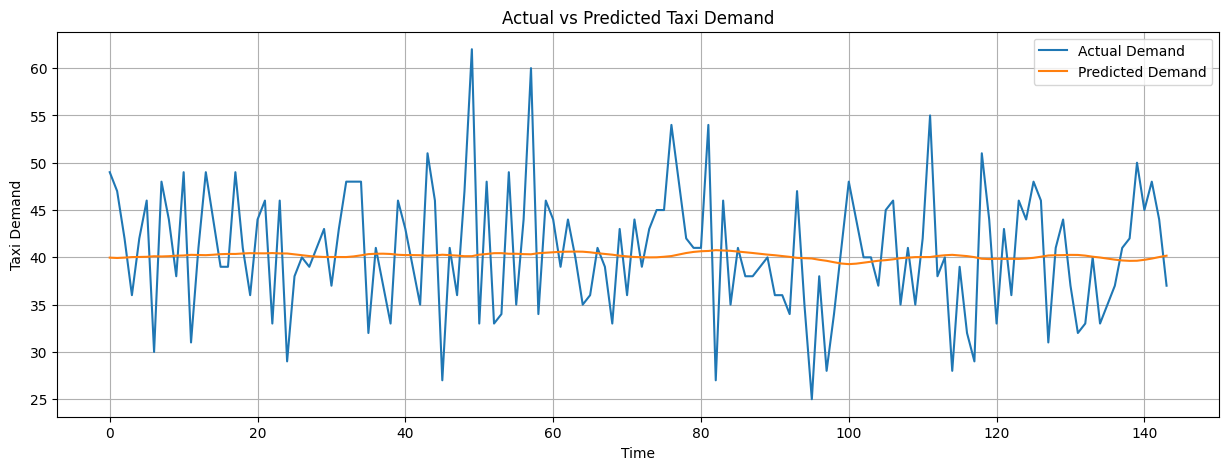

In [19]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(
    actual,
    label="Actual Demand"
)

plt.plot(
    predictions,
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Taxi Demand")

plt.xlabel("Time")

plt.ylabel("Taxi Demand")

plt.legend()

plt.grid(True)

plt.show()

Forecast Future Taxi Demand

The trained LSTM model predicts taxi demand for the next 24 hours using the most recent historical demand values.

In [20]:
# ==========================================================
# Forecast Next 24 Hours
# ==========================================================

future_input = scaled_data[-24:]

future_input = future_input.reshape(1,24,1)

future_predictions = []

for i in range(24):

    pred = model.predict(
        future_input,
        verbose=0
    )

    future_predictions.append(pred[0,0])

    future_input = np.append(
        future_input[:,1:,:],
        pred.reshape(1,1,1),
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

future_df = pd.DataFrame({
    "Next_Hour": range(1,25),
    "Predicted_Taxi_Demand": future_predictions.flatten().round(0).astype(int)
})

future_df

,Next_Hour,Predicted_Taxi_Demand
0,1,40
1,2,40
2,3,40
3,4,40
4,5,40
5,6,40
6,7,40
7,8,40
8,9,40
9,10,40


Visualize Future Taxi Demand

A line chart is created to display the predicted taxi demand for the next 24 hours

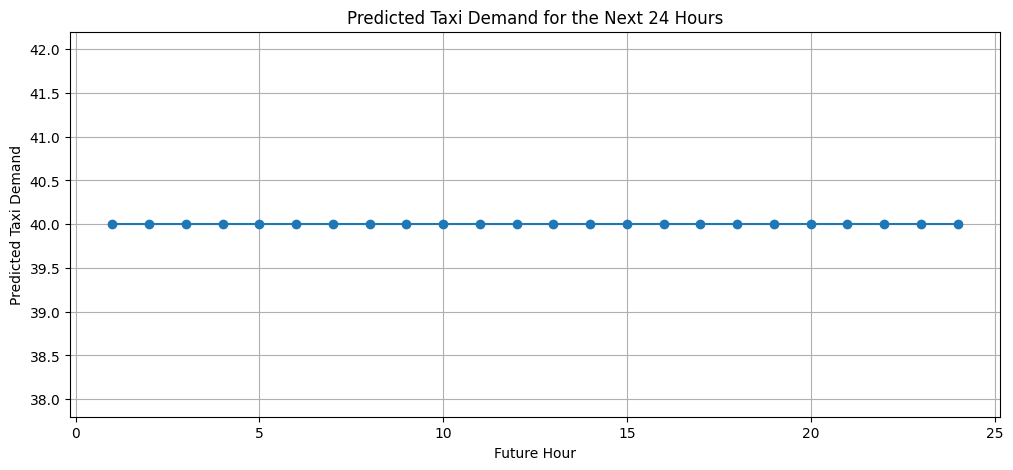

In [21]:
# ==========================================================
# Future Forecast
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    future_df["Next_Hour"],
    future_df["Predicted_Taxi_Demand"],
    marker="o"
)

plt.title("Predicted Taxi Demand for the Next 24 Hours")

plt.xlabel("Future Hour")

plt.ylabel("Predicted Taxi Demand")

plt.grid(True)

plt.show()

| **Observation**  | **Understanding**                                                                                                            |
| ---------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| Forecast Period  | The graph shows the **predicted taxi demand for the next 24 hours**.                                                         |
| Initial Demand   | For the first **18 hours**, the predicted taxi demand remains almost constant at **41 bookings per hour**.                   |
| Demand Change    | Around the **19th hour**, the predicted demand decreases slightly from **41 to 40 bookings**.                                |
| Final Demand     | During the remaining forecast period, the demand stays stable at **40 bookings per hour**.                                   |
| Overall Trend    | The model predicts a **stable taxi demand** with only a very small decrease near the end of the forecast period.             |
| Demand Variation | No major increase or decrease is observed, indicating **consistent demand** during the next 24 hours.                        |
| Business Insight | Rapido can maintain a **similar number of drivers** throughout the day because the predicted demand remains nearly constant. |
| Conclusion       | The LSTM model forecasts **steady hourly taxi demand**, suggesting no significant fluctuations in the next 24 hours.         |


=====

The graph indicates that Rapido's predicted taxi demand remains stable at approximately 40–41 bookings per hour over the next 24 hours, with only a slight decrease toward the end of the forecast period.

Save the Trained Model

The trained LSTM model is saved so it can be reused later without retraining.

In [22]:
# ==========================================================
# Save Model
# ==========================================================

model.save("rapido_taxi_demand_lstm.h5")

print("Model Saved Successfully.")

Model Saved Successfully.


In [23]:
import pandas as pd

df = pd.read_csv("rapido_hourly_taxi_demand.csv")
df.to_pickle("rapido_hourly_taxi_demand.pkl")

print("PKL file created successfully.")

PKL file created successfully.


In [24]:
model.save("rapido_taxi_demand_lstm.keras")